In [ ]:
import zipfile
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/YOLO/BULAI JAGUNG.v7i.yolov8.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("selesai, isi folder:", extract_path)

Mounted at /content/drive
selesai, isi folder: /content/dataset


**Setup: cek GPU, install Ultralytics, lalu mount Google Drive.**

In [ ]:
!nvidia-smi
!pip install -q ultralytics

from google.colab import drive
drive.mount('/content/drive')

import ultralytics
ultralytics.checks()

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 21.9/107.7 GB disk)


**Konfigurasi: semua pengaturan dikumpulkan di satu.**

In [8]:
import zipfile
import shutil
import os

# Menggunakan path yang benar sesuai dengan sel pertama
ZIP_PATH = "/content/drive/MyDrive/YOLO/BULAI JAGUNG.v7i.yolov8.zip"
DATASET_DIR = "/content/dataset"

if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATASET_DIR)

for split in ["train", "valid", "test"]:
    print(f"{split}: {len(os.listdir(f'{DATASET_DIR}/{split}/images'))} gambar (asli, 3 kelas)")

train: 3217 gambar (asli, 3 kelas)
valid: 322 gambar (asli, 3 kelas)
test: 169 gambar (asli, 3 kelas)


In [ ]:
Unzip dan filter: hanya kelas Bulai yang disisakan, lalu foto tanpa Bulai dibuang.

In [9]:
import random
random.seed(SEED)

summary = {}
for split in ["train", "valid", "test"]:
    img_dir = f"{DATASET_DIR}/{split}/images"
    lbl_dir = f"{DATASET_DIR}/{split}/labels"
    kept, bg_kept, removed, boxes = 0, 0, 0, 0
    empty_files = []

    for fname in sorted(os.listdir(lbl_dir)):
        lbl_path = os.path.join(lbl_dir, fname)
        with open(lbl_path) as f:
            lines = [l for l in f.read().splitlines() if l.strip()]

        bulai_lines = [l for l in lines if l.split()[0] == BULAI_CLASS_ID]
        with open(lbl_path, "w") as f:
            f.write("\n".join(bulai_lines) + ("\n" if bulai_lines else ""))

        if bulai_lines:
            kept += 1
            boxes += len(bulai_lines)
        else:
            empty_files.append(fname)

    n_bg = int(kept * BG_RATIO)
    keep_bg = set(random.sample(empty_files, min(n_bg, len(empty_files))))

    for fname in empty_files:
        if fname in keep_bg:
            bg_kept += 1
            continue
        base = os.path.splitext(fname)[0]
        for ext in [".jpg", ".jpeg", ".png"]:
            p = os.path.join(img_dir, base + ext)
            if os.path.exists(p):
                os.remove(p)
                break
        os.remove(os.path.join(lbl_dir, fname))
        removed += 1

    summary[split] = (kept, bg_kept, removed, boxes)
    print(f"{split}: foto bulai={kept}, background={bg_kept}, dibuang={removed}, box bulai={boxes}")

train: foto bulai=1190, background=0, dibuang=2027, box bulai=24145
valid: foto bulai=107, background=0, dibuang=215, box bulai=2300
test: foto bulai=68, background=0, dibuang=101, box bulai=1220


Verifikasi: memastikan jumlah gambar dan label cocok, dan yang tersisa hanya class-id 0.

In [10]:
for split in ["train", "valid", "test"]:
    img_dir = f"{DATASET_DIR}/{split}/images"
    lbl_dir = f"{DATASET_DIR}/{split}/labels"
    imgs = {os.path.splitext(f)[0] for f in os.listdir(img_dir)}
    lbls = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir)}
    ids = set()
    for f in os.listdir(lbl_dir):
        for line in open(os.path.join(lbl_dir, f)):
            if line.strip():
                ids.add(line.split()[0])
    status = "OK" if imgs == lbls and ids <= {"0"} else "!! CEK ULANG"
    print(f"{split}: images={len(imgs)}, labels={len(lbls)}, class-id={ids} -> {status}")

train: images=1190, labels=1190, class-id={'0'} -> OK
valid: images=107, labels=107, class-id={'0'} -> OK
test: images=68, labels=68, class-id={'0'} -> OK


data.yaml ditulis ulang pakai path absolut, supaya tidak muncul error "dataset not found".

In [11]:
import yaml

data_yaml = {
    "path": DATASET_DIR,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 1,
    "names": ["Bulai"],
}
YAML_PATH = f"{DATASET_DIR}/data.yaml"
with open(YAML_PATH, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(open(YAML_PATH).read())

path: /content/dataset
train: train/images
val: valid/images
test: test/images
nc: 1
names:
- Bulai



Cek visual: contoh gambar ditampilkan beserta kotak labelnya, untuk memastikan label menempel di gejala bulai.

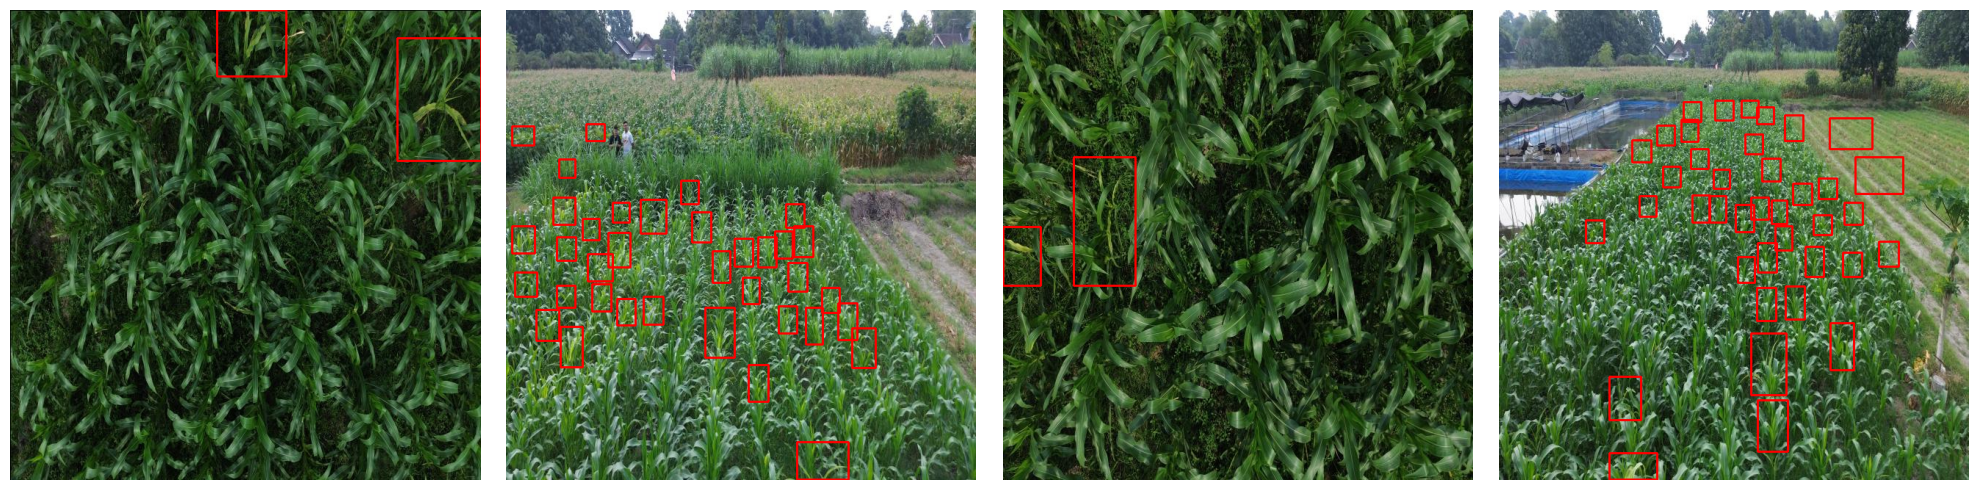

In [12]:
import cv2, glob
import matplotlib.pyplot as plt

samples = random.sample(glob.glob(f"{DATASET_DIR}/train/images/*"), 4)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img_path in zip(axes, samples):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = img_path.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"
    for line in open(lbl_path):
        _, xc, yc, bw, bh = map(float, line.split())
        x1, y1 = int((xc - bw/2) * w), int((yc - bh/2) * h)
        x2, y2 = int((xc + bw/2) * w), int((yc + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    ax.imshow(img); ax.axis("off")
plt.tight_layout(); plt.show()

Training: hasilnya disimpan langsung ke Drive. Tersedia juga sel resume kalau Colab terputus di tengah jalan.

In [ ]:
from ultralytics import YOLO

model = YOLO(MODEL_NAME)

results = model.train(
    data=YAML_PATH,
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=IMGSZ,
    batch=BATCH,
    optimizer="auto",
    flipud=0.5,          # banyak foto drone, orientasi daun bebas
    seed=SEED,
    project=DRIVE_OUT,
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bulai_yolov8s, nbs=64, nms=None, opset=None, optimize=False, o

Grafik hasil: kurva loss, confusion matrix, PR curve, dan F1 curve.

In [ ]:
from IPython.display import Image, display

RUN_DIR = f"{DRIVE_OUT}/{RUN_NAME}"
for name in ["results.png", "confusion_matrix.png", "PR_curve.png", "F1_curve.png"]:
    p = f"{RUN_DIR}/{name}"
    if os.path.exists(p):
        print(name); display(Image(filename=p, width=900))

Evaluasi di data test: menampilkan Precision

In [ ]:
best = YOLO(f"{RUN_DIR}/weights/best.pt")

test_metrics = best.val(data=YAML_PATH, split="test", imgsz=IMGSZ, batch=BATCH,
                        project=DRIVE_OUT, name=f"{RUN_NAME}_test", exist_ok=True)

print("=== Hasil evaluasi data TEST ===")
print(f"Precision : {test_metrics.box.mp:.4f}")
print(f"Recall    : {test_metrics.box.mr:.4f}")
print(f"mAP@50    : {test_metrics.box.map50:.4f}")
print(f"mAP@50-95 : {test_metrics.box.map:.4f}")

Menentukan conf-threshold dari F1 tertinggi,

In [ ]:
import numpy as np

box = test_metrics.box
f1 = np.array(box.f1_curve).mean(0)
p  = np.array(box.p_curve).mean(0)
r  = np.array(box.r_curve).mean(0)
idx = int(f1.argmax())
BEST_CONF = float(box.px[idx])

print(f"conf-threshold terbaik (F1 max): {BEST_CONF:.3f}")
print(f"  -> Precision={p[idx]:.3f}, Recall={r[idx]:.3f}, F1={f1[idx]:.3f}")

print("\nPerbandingan beberapa threshold:")
for c in [0.10, 0.25, 0.40, 0.50, 0.60]:
    i = int(np.abs(np.array(box.px) - c).argmin())
    print(f"  conf={c:.2f}: Precision={p[i]:.3f}, Recall={r[i]:.3f}, F1={f1[i]:.3f}")

Contoh prediksi pada beberapa foto test.

In [ ]:
test_imgs = random.sample(glob.glob(f"{DATASET_DIR}/test/images/*"), 6)
preds = best.predict(test_imgs, conf=BEST_CONF, imgsz=IMGSZ, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, res in zip(axes.flat, preds):
    ax.imshow(res.plot()[:, :, ::-1])
    ax.set_title(f"{len(res.boxes)} deteksi bulai"); ax.axis("off")
plt.tight_layout(); plt.show()

Export ke ONNX. TFLite tersedia sebagai opsi; untuk .engine,

In [ ]:
onnx_path = best.export(format="onnx", imgsz=IMGSZ, simplify=True)
print("ONNX tersimpan di:", onnx_path)

# Opsional untuk Android/edge:
# tflite_path = best.export(format="tflite", imgsz=IMGSZ)

Uji model ONNX: membandingkan hasilnya dengan best.pt.

In [ ]:
onnx_model = YOLO(onnx_path, task="detect")
res_onnx = onnx_model.predict(test_imgs[0], conf=BEST_CONF, imgsz=IMGSZ, verbose=False)[0]
res_pt   = best.predict(test_imgs[0], conf=BEST_CONF, imgsz=IMGSZ, verbose=False)[0]
print(f"Deteksi .pt   : {len(res_pt.boxes)}")
print(f"Deteksi .onnx : {len(res_onnx.boxes)}")